# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


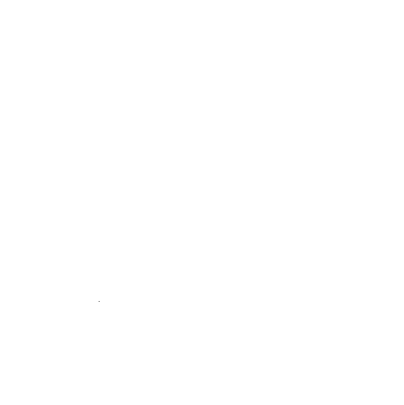

Threshold value: 50


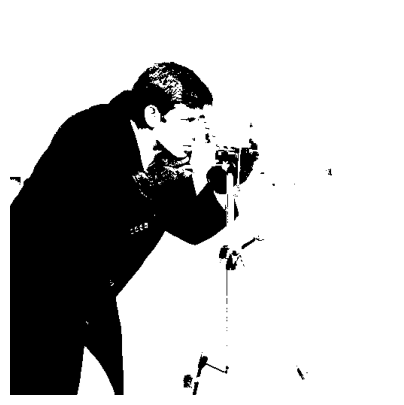

Threshold value: 100


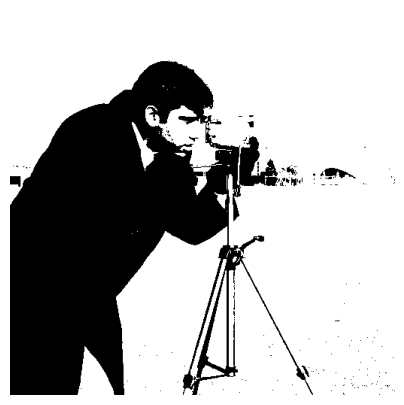

Threshold value: 150


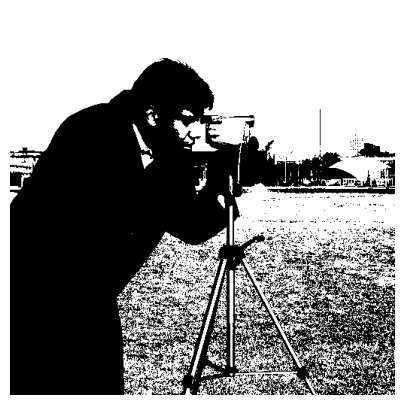

Threshold value: 200


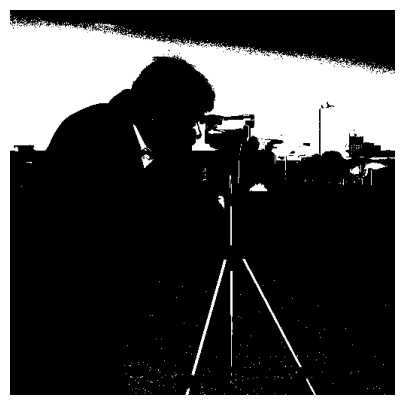

In [4]:
import cv2
import os
import matplotlib.pyplot as plt
from skimage import data

if os.path.exists('cameraman.png'):
    img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)
else:
    img = data.camera()

threshold_values = [0, 50, 100, 150, 200]

for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(
        img, threshold_value, 255, cv2.THRESH_BINARY
    )

    print(f'Threshold value: {threshold_value}')
    plt.figure(figsize=(5, 5))
    plt.imshow(thresh_img, cmap='gray')
    plt.axis('off')
    plt.show()

Original Image:


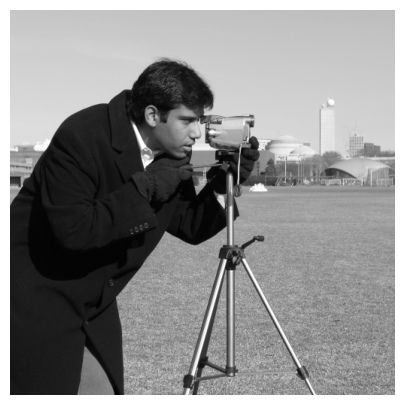

In [5]:
print('Original Image:')
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Histograms

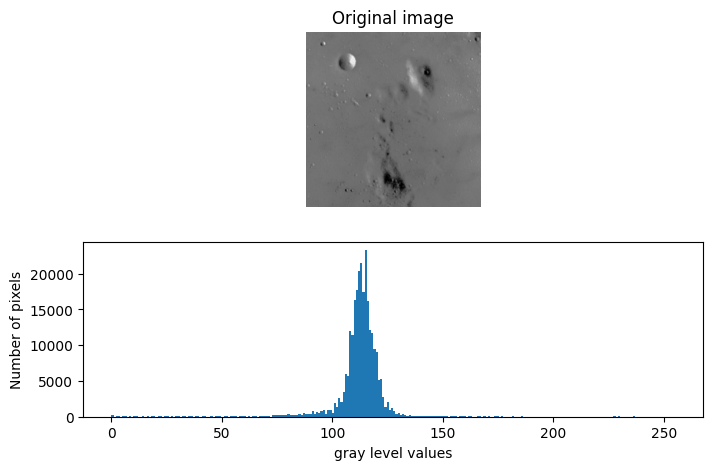

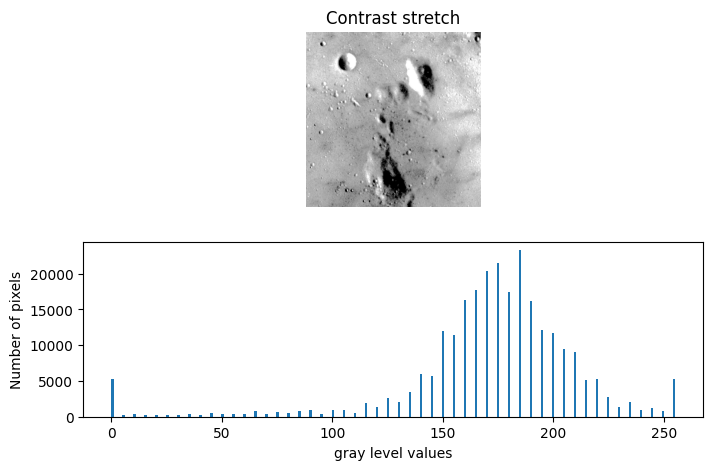

In [6]:
#Task 2: Histogram Processing

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

img = data.moon()

p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


3rd percentile: 87.00
80th percentile: 118.00


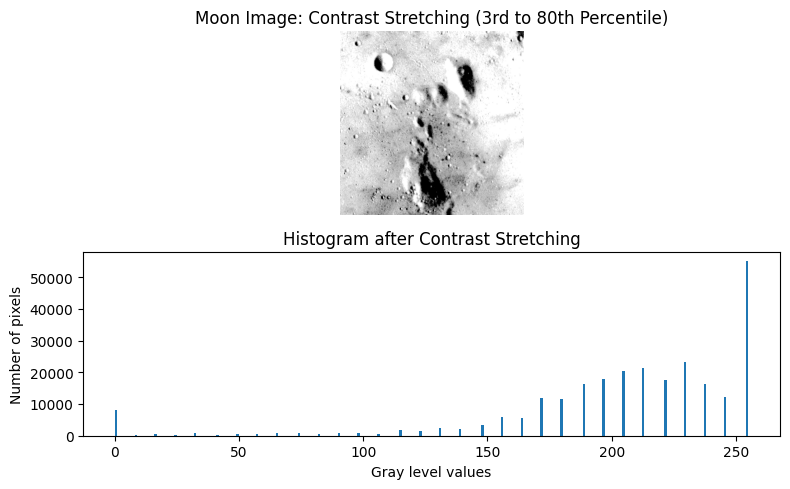

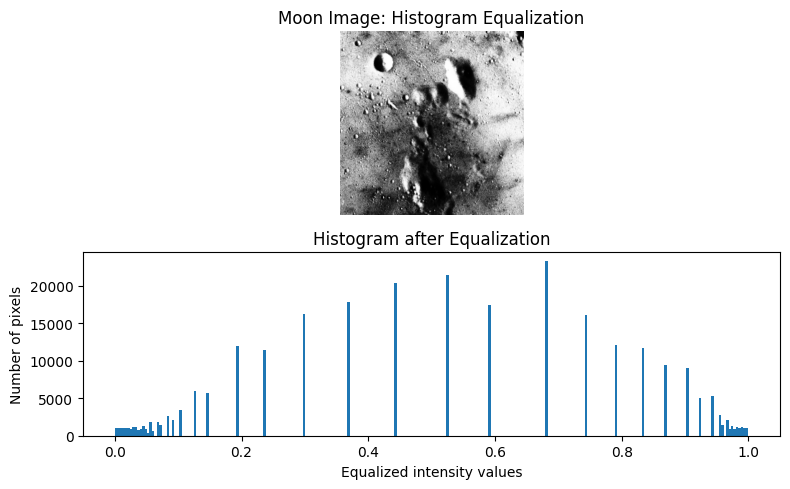

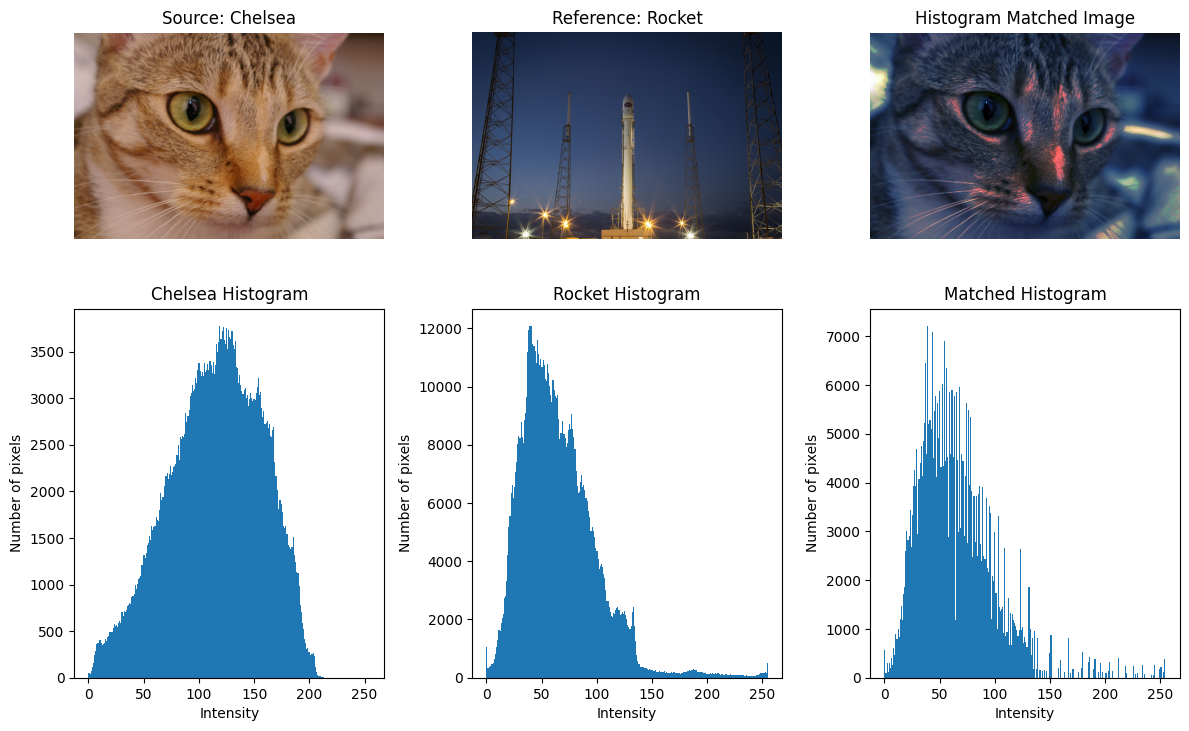

In [7]:
#Task 1: Contrast Stretching
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

print(f'3rd percentile: {p3:.2f}')
print(f'80th percentile: {p80:.2f}')

plt.figure(figsize=(8, 5))
plt.subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Moon Image: Contrast Stretching (3rd to 80th Percentile)')

plt.subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')
plt.title('Histogram after Contrast Stretching')
plt.tight_layout()
plt.show()

#Task 2: Histogram Equalization
img_equalized = exposure.equalize_hist(img)

plt.figure(figsize=(8, 5))
plt.subplot(2, 1, 1)
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')
plt.title('Moon Image: Histogram Equalization')

plt.subplot(2, 1, 2)
plt.hist(img_equalized.flat, bins=256, range=(0, 1))
plt.xlabel('Equalized intensity values')
plt.ylabel('Number of pixels')
plt.title('Histogram after Equalization')
plt.tight_layout()
plt.show()

#Task 3: Histogram Matching

reference = data.rocket()
source = data.chelsea()

matched = exposure.match_histograms(source, reference, channel_axis=-1)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(source)
plt.axis('off')
plt.title('Source: Chelsea')

plt.subplot(2, 3, 2)
plt.imshow(reference)
plt.axis('off')
plt.title('Reference: Rocket')

plt.subplot(2, 3, 3)
plt.imshow(matched)
plt.axis('off')
plt.title('Histogram Matched Image')

plt.subplot(2, 3, 4)
plt.hist(source.ravel(), bins=256, range=(0, 255))
plt.title('Chelsea Histogram')
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')

plt.subplot(2, 3, 5)
plt.hist(reference.ravel(), bins=256, range=(0, 255))
plt.title('Rocket Histogram')
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')

plt.subplot(2, 3, 6)
plt.hist(matched.ravel(), bins=256, range=(0, 255))
plt.title('Matched Histogram')
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()